Installation

In [31]:
!pip install gensim

Imports

In [32]:
import pandas as pd
import numpy as np
import gensim.downloader as api
import matplotlib.pyplot as plt
import seaborn as sns
import random
import tensorflow as tf
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

Load data (the datafile has to be added in the "files")

In [33]:
df = pd.read_csv('/content/PERFECT2_cleaned_reddit_opinion-2.csv')
texts = df['cleaned_text'].astype(str).tolist()
labels = df['sentiment_label'].values

Produce the same result everytime

In [34]:
os.environ['PYTHONHASHSEED'] = '0'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
tf.config.experimental.enable_op_determinism()

Tokenization

In [35]:
MAX_NB_WORDS = 20000
MAX_SEQUENCE_LENGTH = 220
tokenizer = Tokenizer(num_words=MAX_NB_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
X = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

Load GloVe


In [36]:
print("Loading GloVe 300d...")
glove = api.load('glove-wiki-gigaword-300') # 376MB download
embedding_dim = 300 # 300 dimensions

Loading GloVe 300d...


Create embedding matrix

In [37]:
embedding_matrix = np.zeros((MAX_NB_WORDS, embedding_dim))
for word, i in tokenizer.word_index.items():
    if i < MAX_NB_WORDS and word in glove:
        embedding_matrix[i] = glove[word]

Train/test split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.2, random_state=42, stratify=labels)

CNN model

In [39]:
model = Sequential([
    Embedding(MAX_NB_WORDS, embedding_dim, weights=[embedding_matrix], trainable=True),
    Conv1D(128, 5, activation='relu'),          # 5-gram filters
    GlobalMaxPooling1D(),                       # take max over time
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,000,000 (22.89 MB)

 Trainable params: 6,000,000 (22.89 MB)

 Non-trainable params: 0 (0.00 B)

Training

In [40]:
history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=30,
                    batch_size=32,
                    verbose=1)

Epoch 1/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 15s 177ms/step - accuracy: 0.4776 - loss: 1.0259 - val_accuracy: 0.5556 - val_loss: 0.9299
Epoch 2/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 12s 159ms/step - accuracy: 0.6485 - loss: 0.7809 - val_accuracy: 0.6235 - val_loss: 0.8280
Epoch 3/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 12s 157ms/step - accuracy: 0.8249 - loss: 0.4722 - val_accuracy: 0.6517 - val_loss: 0.7827
Epoch 4/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 20s 157ms/step - accuracy: 0.9498 - loss: 0.1883 - val_accuracy: 0.6650 - val_loss: 0.8578
Epoch 5/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 12s 163ms/step - accuracy: 0.9784 - loss: 0.0912 - val_accuracy: 0.6252 - val_loss: 1.4190
Epoch 6/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 12s 164ms/step - accuracy: 0.9614 - loss: 0.1142 - val_accuracy: 0.6534 - val_loss: 1.1787
Epoch 7/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 12s 155ms/step - accuracy: 0.9527 - loss: 0.1343 - val_accuracy: 0.6667 - val_loss: 1.0839
Epoch 8/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 12s 163ms/step - accuracy: 0.9871 - loss: 0.0413 - val_accu

Evaluate

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
Accuracy: 0.705

Per-class metrics:
  Class 0: Precision = 0.722, Recall = 0.718, F1 = 0.720
  Class 1: Precision = 0.702, Recall = 0.777, F1 = 0.737
  Class 2: Precision = 0.691, Recall = 0.575, F1 = 0.627


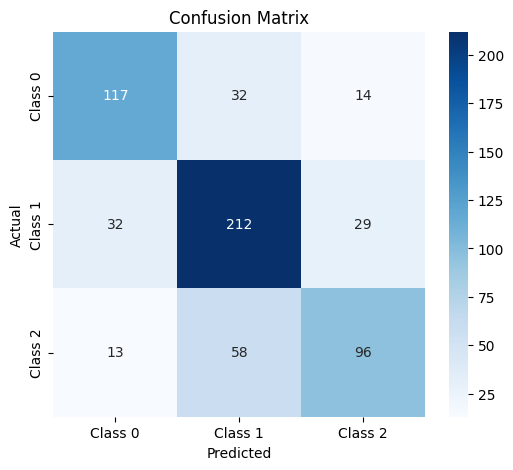

In [41]:
# Get predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None)

# Print metrics clearly
print(f"Accuracy: {accuracy:.3f}\n")
print("Per-class metrics:")
class_names = ['Class 0', 'Class 1', 'Class 2']
for i, name in enumerate(class_names):
    print(f"  {name}: Precision = {precision[i]:.3f}, Recall = {recall[i]:.3f}, F1 = {f1[i]:.3f}")

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1', 'Class 2'],
            yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()